[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/xiptos/is_notes/blob/main/logistic_regression_exercise.ipynb)

# Multiple variable binary classification

This exercise is an introduction to logistic regression, using the brest cancer dataset dataset.

## Dataset

Loading the dataset. We will be using the [Brest Cancer Wisconsin (Diagnostic)](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic), downloaded from the [Scikit Datasets](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html#sklearn.datasets.load_breast_cancer)

In [2]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import seaborn as sns

X,y = load_breast_cancer(return_X_y=True,as_frame=True)
df = X
df['diagnosis'] = y

Check the dataframe shape as well as the content.

In [3]:
df.shape

(569, 31)

In [7]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Also get some info about the dataset

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

Use descriptive statistics to get information about the `X` dataset

In [8]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


Check for missing values

In [16]:
i = 0

for col in df.columns:
  for val in df[col]:
    if(pd.isna(val) or pd.isnull(val)):
      i+=1

print(i)

0


## Univariate analysis

Plot the histogram of the labels `df['diagnosis']`

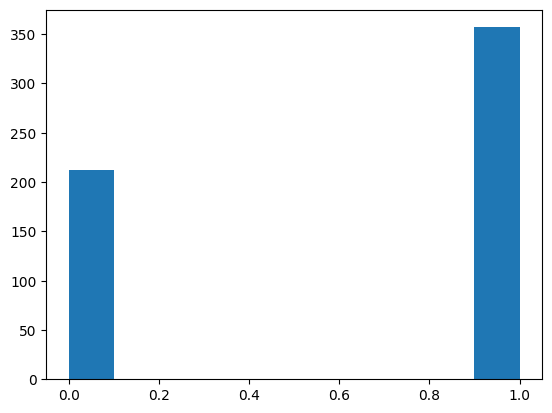

In [23]:
import matplotlib.pyplot as plt
plt.hist(df['diagnosis'])
plt.show()

## Positive Correlation

Plot, using seaborn, scatterplots of the following variables, considering the label `df['diagnosis']` as the `hue`:
- `mean perimeter` vs. `worst radius`
- `mean area` vs. `worst radius`
- `mean texture` vs. `worst texture`
- `worst area` vs. `worst radius`

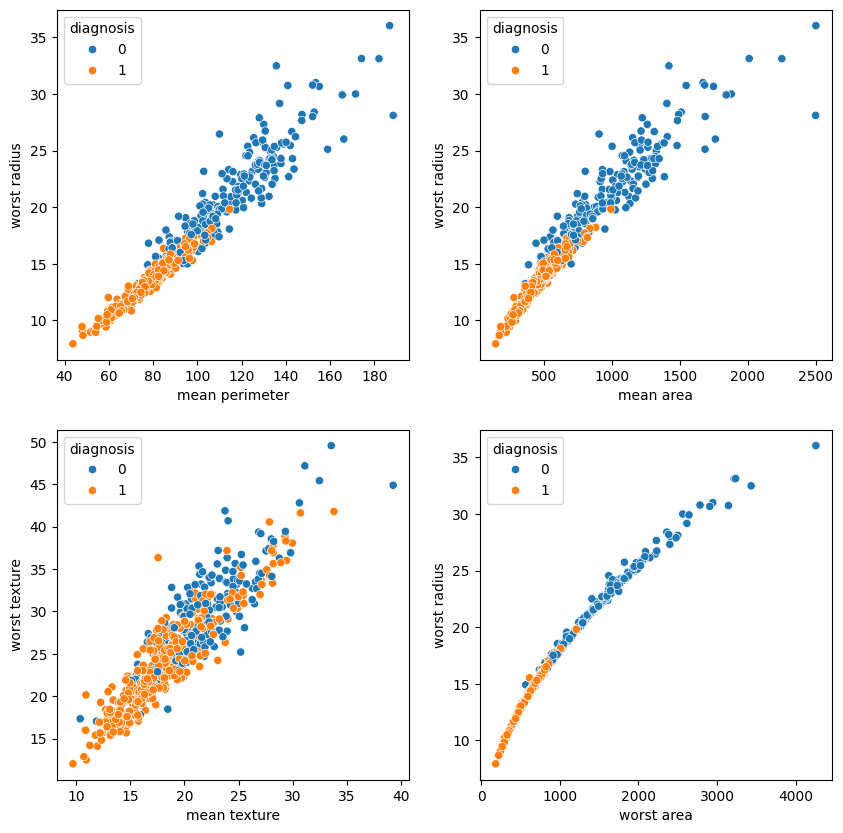

In [32]:
plt.figure(figsize=(10,10))
plt.subplot(2,2,1)
sns.scatterplot(data=df,x='mean perimeter',y='worst radius',hue='diagnosis')
plt.subplot(2,2,2)
sns.scatterplot(data=df,x='mean area',y='worst radius',hue='diagnosis')
plt.subplot(2,2,3)
sns.scatterplot(data=df,x='mean texture',y='worst texture',hue='diagnosis')
plt.subplot(2,2,4)
sns.scatterplot(data=df,x='worst area',y='worst radius',hue='diagnosis')
plt.show()

## Negative Correlation

Plot, using seaborn, scatterplots of the following variables, considering the label `df['diagnosis']` as the `hue`:
- `mean area` vs. `mean fractal dimention`
- `mean radius` vs. `smoothness error`
- `smoothness error` vs. `mean perimeter`
- `mean area` vs. `smoothness error`

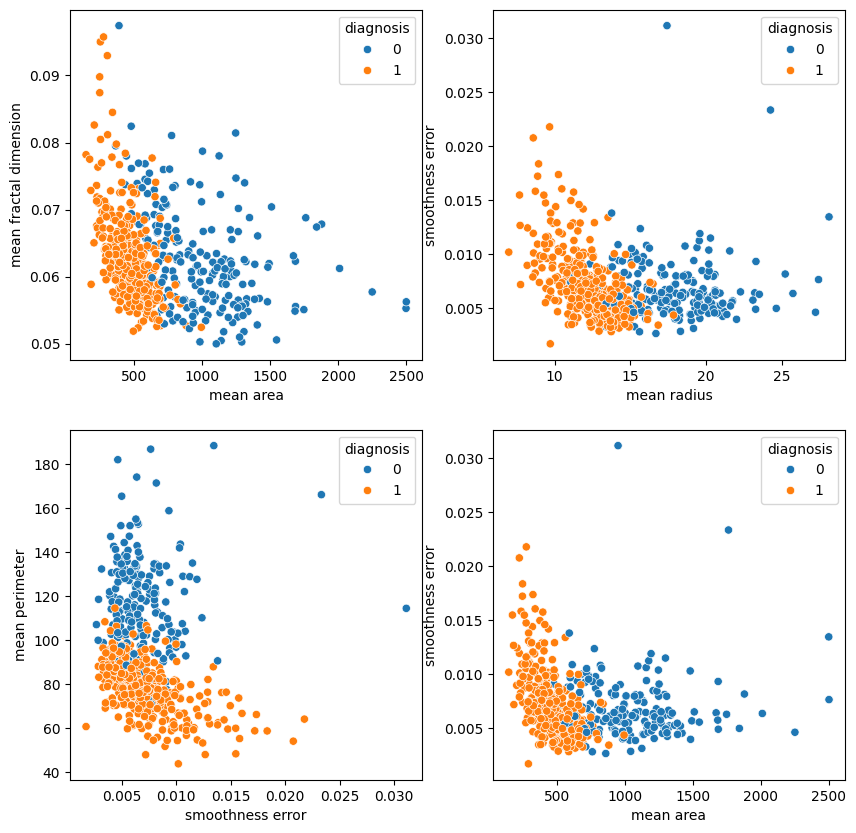

In [30]:
plt.figure(figsize=(10,10))
plt.subplot(2,2,1)
sns.scatterplot(data=df,x='mean area',y='mean fractal dimension',hue='diagnosis')
plt.subplot(2,2,2)
sns.scatterplot(data=df,x='mean radius',y='smoothness error',hue='diagnosis')
plt.subplot(2,2,3)
sns.scatterplot(data=df,x='smoothness error',y='mean perimeter',hue='diagnosis')
plt.subplot(2,2,4)
sns.scatterplot(data=df,x='mean area',y='smoothness error',hue='diagnosis')
plt.show()

## Distribution plot

Plot the histogram of the `mean radius`.

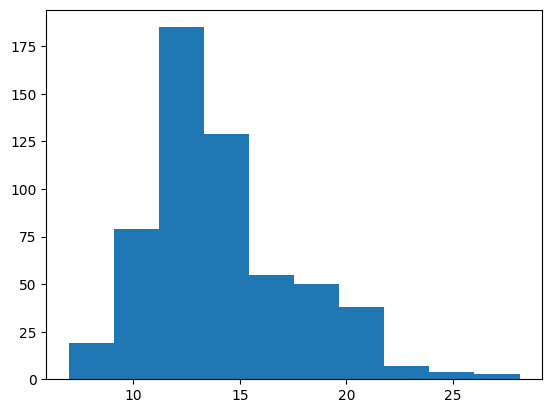

In [26]:
plt.hist(df['mean radius'])
plt.show()

## Correlation Matrix

Plot the correlation matrix using seaborn heatmap.

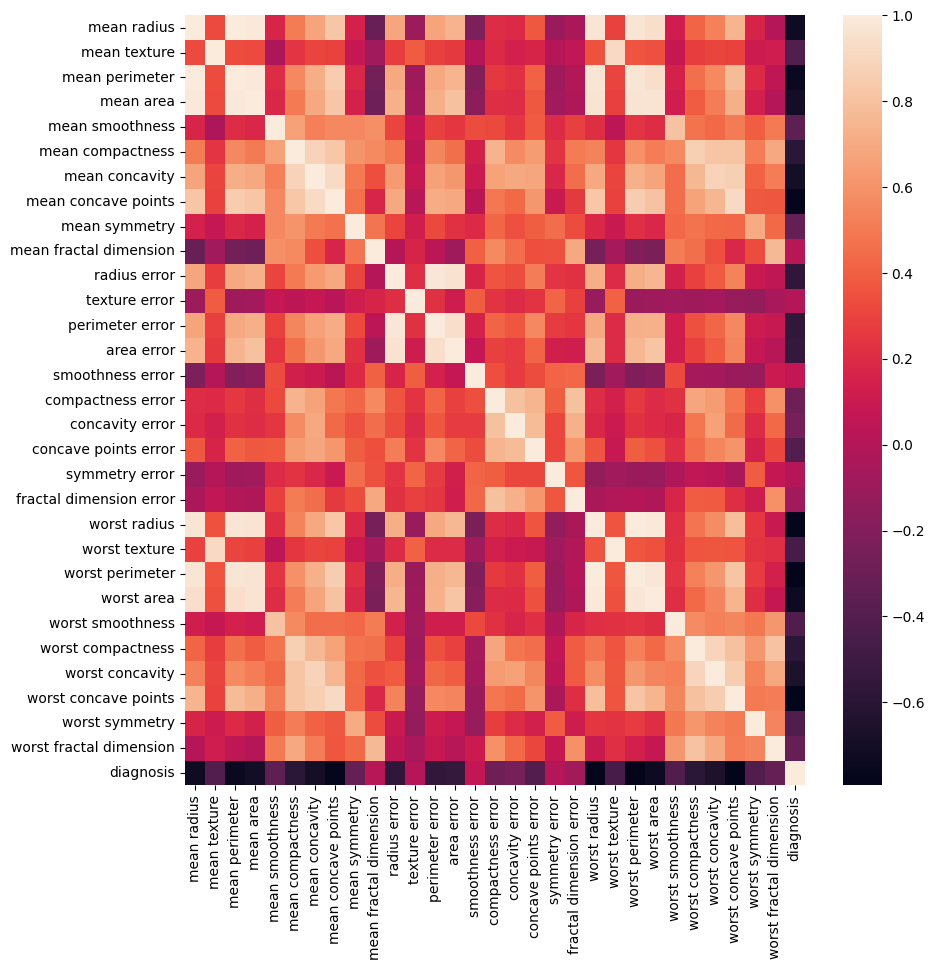

In [31]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr())
#df.corr()
plt.show()

# Data Preprocessing

Encode the labels `y` with scikit learn `LabelEncoder`.

In [55]:
import sklearn.preprocessing
sklearn.preprocessing.LabelEncoder()
y = sklearn.preprocessing.LabelEncoder().fit_transform(y)

## Train Test Split

Split `X` and `y` into a training and testing sets, with 10% testing size.

In [56]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.1)

## Feature scaling

Normalize the fratures using scikit learn `StandardScaler`

In [57]:
from sklearn import preprocessing
scaler = preprocessing.StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# Train the model

Train a logistic model for predicting the diagnosis of brest cancer using the features of the dataset.

In [58]:
from sklearn import linear_model
model = linear_model.LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

# Evaluate the model

Calculate the predictions `y_pred` for the `X_test` set.

In [59]:
y_pred = model.predict(X_test)

Print the accuracy using scikit metrics `accuracy_score` function.

In [60]:
from sklearn import metrics
acc = sklearn.metrics.accuracy_score(y_test,y_pred)
print(acc)

1.0


Print the confusion matrix using scikit metrics' `confusion_matrix` function

In [61]:
sklearn.metrics.confusion_matrix(y_test,y_pred)

array([[15,  0],
       [ 0, 42]])

Finally, plot the confusion matrix using seaborn's `heatmap`.

<Axes: >

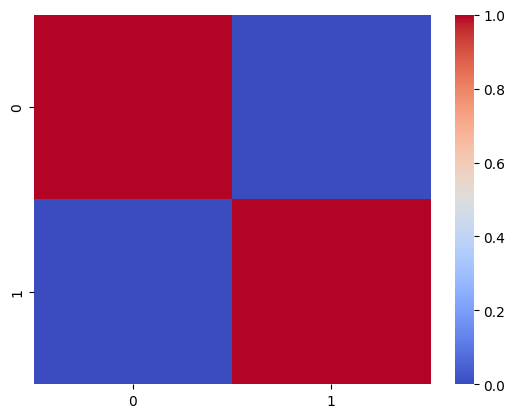

In [62]:
#sns.heatmap(sklearn.metrics.confusion_matrix(y_test,y_pred))

# in percentage

#sns.heatmap(sklearn.metrics.confusion_matrix(y_test,y_pred)/len(y_test), cmap="coolwarm")

# accuracy matrix

sns.heatmap(sklearn.metrics.confusion_matrix(y_test,y_pred)/sklearn.metrics.confusion_matrix(y_test,y_pred).sum(axis=1)[:,None], cmap="coolwarm")

Model Parameters:
Intercept: 0.8861
Coefficients for first 5 features: [-0.24367567 -0.26767479 -0.23841795 -0.26387843 -0.14669237]


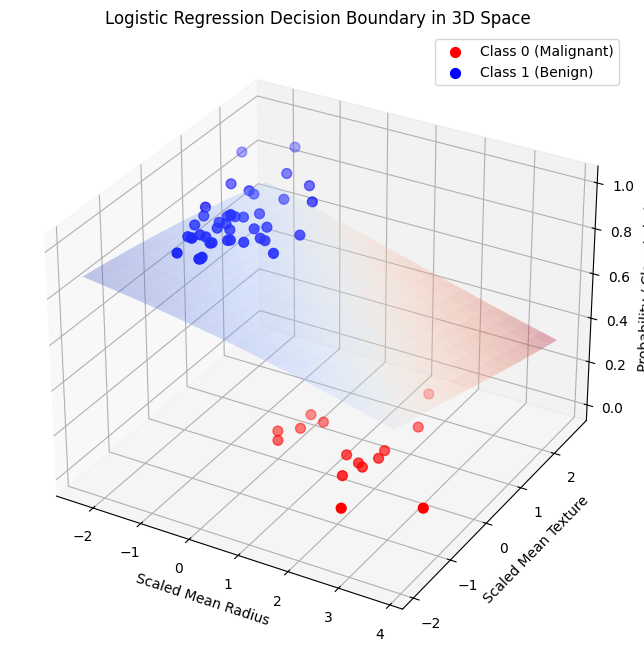

In [67]:
import numpy as np
import matplotlib.pyplot as plt

# Retrieve model parameters
coef = model.coef_[0]
intercept = model.intercept_[0]

print("Model Parameters:")
print(f"Intercept: {intercept:.4f}")
print(f"Coefficients for first 5 features: {coef[:5]}")

# Since there are 30 features, we can visualize a 3D decision boundary
# using the first two features (index 0 and 1) by fixing the other features to their mean (0 in standard scaled space).
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of test set (first two features)
x1 = X_test[:, 0]
x2 = X_test[:, 1]
y_val = y_test

ax.scatter(x1[y_val == 0], x2[y_val == 0], y_val[y_val == 0], color='red', label='Class 0 (Malignant)', s=50)
ax.scatter(x1[y_val == 1], x2[y_val == 1], y_val[y_val == 1], color='blue', label='Class 1 (Benign)', s=50)

# Create a grid for the first two features
x1_range = np.linspace(x1.min() - 0.5, x1.max() + 0.5, 20)
x2_range = np.linspace(x2.min() - 0.5, x2.max() + 0.5, 20)
X1_grid, X2_grid = np.meshgrid(x1_range, x2_range)

# Calculate the decision hyperplane z-values (probability = 0.5, meaning log-odds = 0)
# log-odds = intercept + w0*x0 + w1*x1 + sum(wi*xi) = 0
# Since other features are scaled and centered around 0, their contributions can be approximated to 0.
# We can plot the plane where the probability is modeled: p = 1 / (1 + exp(-z))
# z_log_odds = intercept + w0 * X1 + w1 * X2
Z_grid = 1 / (1 + np.exp(-(intercept + coef[0] * X1_grid + coef[1] * X2_grid)))

# Plot decision surface
ax.plot_surface(X1_grid, X2_grid, Z_grid, alpha=0.3, cmap='coolwarm_r')

ax.set_xlabel('Scaled Mean Radius')
ax.set_ylabel('Scaled Mean Texture')
ax.set_zlabel('Probability / Class Label')
ax.set_title('Logistic Regression Decision Boundary in 3D Space')
ax.legend()
plt.show()

## Classification Metrics

Displaying precision, recall and F1-score.

In [68]:
from sklearn.metrics import classification_report

# Calculate and print classification metrics
report = classification_report(y_test, y_pred)
print("Relatório de Classificação:\n")
print(report)

Relatório de Classificação:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        42

    accuracy                           1.00        57
   macro avg       1.00      1.00      1.00        57
weighted avg       1.00      1.00      1.00        57

